# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Research question

Which content items should editors prioritize for refreshing first when editorial resources are limited?

### Decision

The work supports the decision of which content pages should receive editorial attention first.

### Who acts?

SEO specialists and content editors use the ranked output to decide which pages should be reviewed for a possible refresh.

### Action

The output ranks content items by observed search visibility and identifies stale, visible pages for `refresh_first` review.

The goal is not to automatically decide what change should be made. The goal is to help humans prioritize limited editorial effort.

In [1]:
print("Research question:")
print("Which content items should editors prioritize for refreshing first?")
print()
print("Decision: prioritize pages for human editorial review.")
print("Primary action: refresh_first for stale + visible pages.")

Research question:
Which content items should editors prioritize for refreshing first?

Decision: prioritize pages for human editorial review.
Primary action: refresh_first for stale + visible pages.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

The project uses the FlyRank Search Intelligence starter dataset and the full warehouse release used during the internship.

The starter dataset contains 30,000 pseudonymized content items across 32 pseudonymized clients. Each row represents one content item and contains aggregated search, traffic, content, and trend signals.

For the final warehouse workflow, the relevant tables are:

- `dim_clients` — client history and data-availability information.
- `dim_content` — content metadata and keyword context.
- `fact_content_daily_performance` — daily client × content performance.
- `fact_content_query_90d` — query-level search context.

The warehouse covers approximately 17 months of daily search performance.

For development, a mid-panel period such as March 2026 was used rather than developing against the final June 2026 sample. The final month is treated as a sealed outcome period.

### Excluded information

Client identifiers and content identifiers are used only for grouping and joining and are not model features.

`trend_direction` and `trend_pct` are excluded from model features because the declining label is derived from them. Including them would leak the outcome into the features.

Private client names, domains, URLs, queries, credentials, and raw exports are not included in the public research paper.

In [2]:
import pandas as pd
!git clone https://github.com/flyrank-bih/flyrank-ml-internship-starter.git
%cd flyrank-ml-internship-starter
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique clients:", df["client_id"].nunique())
print("Missing avg_position:", (df["avg_position"] == 0).sum())

Cloning into 'flyrank-ml-internship-starter'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (151/151), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 299 (delta 118), reused 86 (delta 86), pack-reused 148 (from 2)
Receiving objects: 100% (299/299), 1.88 MiB | 4.77 MiB/s, done.
Resolving deltas: 100% (161/161), done.
/content/flyrank-ml-internship-starter
Rows: 30000
Columns: 44
Unique clients: 32
Missing avg_position: 1205


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### Task type

The lane is framed as a ranking / scoring problem.

The goal is to produce a priority score that helps determine which pages should be reviewed first.

### Baseline

The baseline uses two observable signals:

1. Staleness: `days_since_last_update >= 180`
2. Visibility: `impressions_90d >= 500`

A page satisfying both conditions receives a priority score equal to its observed 90-day impressions.

The reason code is `stale_visible` and the recommended action is `refresh_first`.

### Machine-learning model

A Random Forest classifier was tested using observable content and search-performance features.

The model was evaluated against the simpler baseline rather than being judged by complexity alone.

### Target

For the classification experiment, the target was an observed declining outcome based on the defined trend label. Outcome-derived fields were not used as features.

### Validation

The model was also evaluated using client-grouped validation so that pages belonging to the same client were not simultaneously used for training and evaluation.

This is more conservative than a random row-level split because content from the same client can share characteristics.

### Leakage checks

The feature set was checked for outcome-derived fields.

In particular, `trend_pct` and `trend_direction` were excluded because the declining label is derived from them.

The final methodology therefore uses only signals that are available before the decision or are otherwise aligned with the evaluation window.

### Evaluation metric

Precision@K is used because the practical question is whether the highest-ranked recommendations contain a useful proportion of relevant pages.

The same metric is used when comparing the baseline and the model.

In [3]:
results = pd.DataFrame({
    "K": [10, 20, 50],
    "Baseline_Precision": [0.60, 0.50, 0.62],
    "Model_Precision": [0.40, 0.40, 0.52]
})

results["Difference"] = (
    results["Model_Precision"]
    - results["Baseline_Precision"]
)

display(results)

,K,Baseline_Precision,Model_Precision,Difference
0,10,0.60,0.40,-0.2
1,20,0.50,0.40,-0.1
2,50,0.62,0.52,-0.1


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

The simpler baseline performed better than the tested Random Forest at all three evaluated values of K.

At K=10, the baseline Precision@10 was 0.60 compared with 0.40 for the model.

At K=20, the baseline was 0.50 compared with 0.40 for the model.

At K=50, the baseline was 0.62 compared with 0.52 for the model.

Therefore, in this experiment, increasing model complexity did not produce a better ranked queue than the simple stale-and-visible rule.

The result supports retaining the simpler baseline as the current decision-support approach.

These results are measured on the evaluated data and should not be interpreted as proof that the baseline will always outperform machine-learning models on future data.

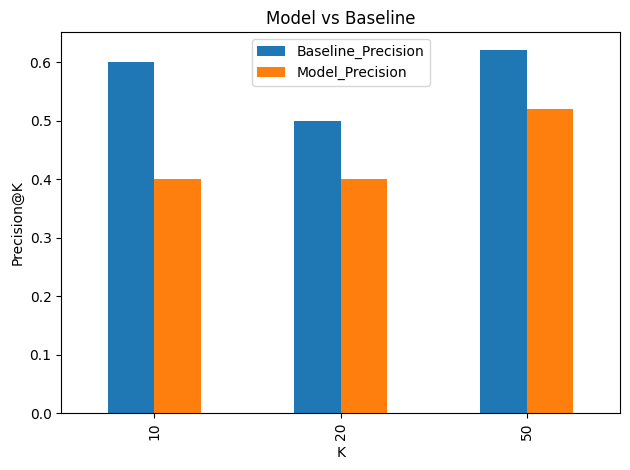

In [4]:
import matplotlib.pyplot as plt

results.plot(
    x="K",
    y=["Baseline_Precision", "Model_Precision"],
    kind="bar"
)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Model vs Baseline")
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This work has several important limitations.

First, the data contains pseudonymized clients and does not provide the full business context that an editor would have when making a real content decision.

Second, the analysis is observational. It can identify patterns and produce directional recommendations, but it cannot prove that refreshing a page causes better rankings, traffic, clicks, or engagement.

Third, search performance is affected by many external factors that are not represented in the available data.

Fourth, history depth differs between clients, so a single calendar window does not represent identical historical coverage for every client.

Fifth, the tested Random Forest did not outperform the simpler baseline under the evaluated metrics. This means the evidence does not justify claiming that the more complex model provides additional decision value.

Finally, the ranked output is decision-support rather than an automated content-management system. Human review is required before taking editorial action.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

### Primary recommendation: Refresh first

Prioritize pages that satisfy:

- `days_since_last_update >= 180`
- `impressions_90d >= 500`

These pages receive the `stale_visible` reason code and `refresh_first` action.

Within this group, pages with higher observed impressions receive higher priority because they represent greater observed search exposure.

### Other archetypes

| Archetype | Recommended action |
|---|---|
| Stale + visible | Refresh first |
| Recent + visible | Monitor |
| Stale + low visibility | Monitor / investigate |
| Recent + low visibility | Monitor |

### Human review

Every `refresh_first` recommendation should be reviewed by an SEO specialist or content editor.

The reviewer should consider search intent, content accuracy, relevance, business context, and whether a refresh is actually appropriate.

### What should not be automated

The system should not automatically publish changes, delete pages, rewrite content, change metadata, or claim that a refresh will improve search performance.

The output is a ranked decision-support queue, not an autonomous content-management system.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

The capstone paper will use:

1. A model-vs-baseline Precision@K chart.
2. A results table showing the measured Precision@10, Precision@20, and Precision@50.
3. A ranked recommendation table generated from the baseline action queue.

The artifacts are generated from the notebook so that the research paper can be traced back to the analysis.

In [5]:
import os

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

results.to_csv(
    "work/outputs/model_vs_baseline_metrics.csv",
    index=False
)

display(results)

print("Saved: work/outputs/model_vs_baseline_metrics.csv")

,K,Baseline_Precision,Model_Precision,Difference
0,10,0.60,0.40,-0.2
1,20,0.50,0.40,-0.1
2,50,0.62,0.52,-0.1


Saved: work/outputs/model_vs_baseline_metrics.csv


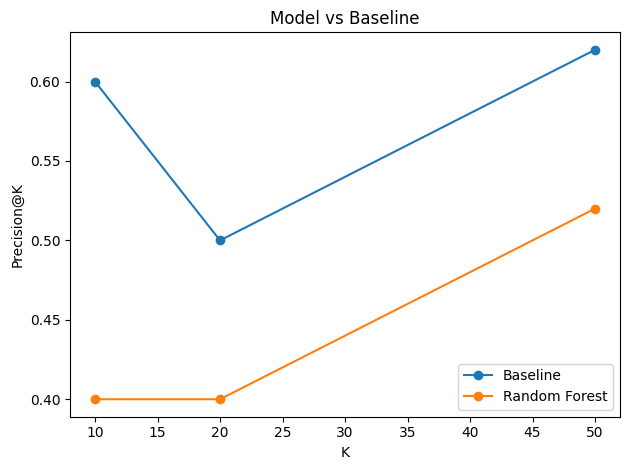

In [6]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    results["K"],
    results["Baseline_Precision"],
    marker="o",
    label="Baseline"
)

plt.plot(
    results["K"],
    results["Model_Precision"],
    marker="o",
    label="Random Forest"
)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Model vs Baseline")
plt.legend()
plt.tight_layout()

plt.savefig(
    "work/figures/model_vs_baseline_precision.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [7]:
df["stale"] = df["days_since_last_update"] >= 180
df["visible"] = df["impressions_90d"] >= 500

df["baseline_score"] = (
    df["stale"].astype(int)
    * df["visible"].astype(int)
    * df["impressions_90d"]
)

df["reason_code"] = "not_priority"
df.loc[
    df["stale"] & df["visible"],
    "reason_code"
] = "stale_visible"

df["action"] = "monitor"
df.loc[
    df["stale"] & df["visible"],
    "action"
] = "refresh_first"

queue = df.sort_values(
    "baseline_score",
    ascending=False
)

display(
    queue[
        [
            "content_id",
            "days_since_last_update",
            "impressions_90d",
            "baseline_score",
            "reason_code",
            "action"
        ]
    ].head(20)
)

,content_id,days_since_last_update,impressions_90d,baseline_score,reason_code,action
16751,content_cf56e2e2e282,194,61678,61678,stale_visible,refresh_first
16514,content_7368877ea310,194,59472,59472,stale_visible,refresh_first
7021,content_1bfaa38ff26c,194,25715,25715,stale_visible,refresh_first
21268,content_0a91db491d14,193,13299,13299,stale_visible,refresh_first
11489,content_5feee3994adb,194,7812,7812,stale_visible,refresh_first
12045,content_c2d929d83eaa,193,7558,7558,stale_visible,refresh_first
698,content_b16bd7307b39,194,4590,4590,stale_visible,refresh_first
5327,content_fe16a55cd13d,194,4556,4556,stale_visible,refresh_first
26810,content_ecb6215e79fd,194,4429,4429,stale_visible,refresh_first
20837,content_928af3e22c80,193,1697,1697,stale_visible,refresh_first


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
